### Data Quality Summary & Resolution

## 1. High-Level Summary
| Dataset   | Rows   | Cols | Missing Cols | Duplicate IDs | Range Issues | Domain Issues | IQR Outliers |
|-----------|--------|------|---------------|---------------|--------------|---------------|--------------|
| **Generic** | 64,374 | 12   | 0             | 0             | 0            | 0             | 0            |

---

## 2. Generic Dataset Issues
- Missing Values: **None**
- Duplicates: **None**
- Outliers: **None**
- Domain/Range Issues: **None**

Dataset is already **clean and ready for use**



# Data Preparation
This notebook documents the **data preparation process** for the Generic customer churn datasets.  
The primary goals are to clean, preprocess, and explore the raw data to ensure it is ready for downstream modeling tasks.  

### Objectives
1. **Inspect raw datasets** to understand structure, completeness, and quality.  
2. **Handle missing values** through imputation or removal where necessary.  
3. **Standardize/normalize numerical attributes** and treat outliers using IQR-based winsorization.  
4. **Encode categorical features** appropriately for machine learning workflows.  
5. **Perform Exploratory Data Analysis (EDA):**  
   - Quantify missingness  
   - Univariate analysis of features and the target  
   - Bivariate analysis (feature–target and feature–gender relationships)  
   - Multivariate patterns via correlation analysis  
6. **Generate artifacts:**  
   - Clean datasets ready for transformation and modeling  
   - Visualizations (histograms, box plots, target rates, correlations) saved for reporting  
   - A summary report documenting the cleaning steps applied  


In [14]:
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# you must already have df_generic in memory
if "df_generic" not in globals():
    raise RuntimeError("Please load df_generic first.")

# work on copies (do not touch masters)
generic = df_generic.copy()

# output folders
GENERIC_OUT = "/content/drive/MyDrive/DMML_Project/data/clean/generic"
PLOTS_GENERIC_DIR = "/content/drive/MyDrive/DMML_Project/data/plots/generic"

for p in [GENERIC_OUT, PLOTS_GENERIC_DIR]:
    Path(p).mkdir(parents=True, exist_ok=True)

# plotting behavior
SAVE_PLOTS = True
SHOW_PLOTS = True
sns.set_theme(style="whitegrid", context="notebook")

TS = datetime.now().strftime("%Y%m%dT%H%M%S")

# target: always 'Churn' as requested
TARGET_COL = "Churn"

print("target (generic dataset):", TARGET_COL)

target (generic dataset): Churn


In [15]:
def save_show(fig, path):
    if SAVE_PLOTS:
        fig.savefig(path, dpi=140, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

def num_cols(df):
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def show_missingness(df, title, out_dir, fname):
    miss = df.isna().sum().rename("missing_count")
    miss = miss[miss > 0].sort_values(ascending=False)
    print(f"\n{title}")
    if miss.empty:
        print("no missing values")
        return
    display(miss.to_frame())
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=miss.index, y=miss.values, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("column"); ax.set_ylabel("missing_count")
    ax.tick_params(axis="x", rotation=75)
    save_show(fig, os.path.join(out_dir, fname))

def coerce_numeric_inplace(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

def is_binary_series(s):
    u = pd.Series(s.dropna().unique())
    return u.isin([0,1]).all() and u.nunique() <= 2

def drop_iqr_outliers_inplace(df, cols, skip_binary=True):

    #Drop rows outside IQR bounds for each column in `cols`.

    stats = {}
    to_drop_idx = set()
    for c in cols:
        if c not in df.columns or not pd.api.types.is_numeric_dtype(df[c]):
            continue
        if skip_binary and is_binary_series(df[c]):
            # skip binary outlier logic
            continue
        s = df[c].dropna()
        if len(s) < 5:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
        mask = (df[c] < lo) | (df[c] > hi)
        dropped = int(mask.sum())
        stats[c] = {"dropped": dropped, "lo": float(lo), "hi": float(hi)}
        if dropped > 0:
            to_drop_idx.update(df.index[mask].tolist())
    dropped_total = len(to_drop_idx)
    if dropped_total > 0:
        df.drop(index=list(to_drop_idx), inplace=True)
        df.reset_index(drop=True, inplace=True)
    return stats, dropped_total

def to_binary_series_like_churn(s):

    # Map common yes/no strings to 1/0 for rate plots. If s is already numeric,

    if pd.api.types.is_numeric_dtype(s):
        return s
    mapping = {"yes":1, "no":0, "true":1, "false":0, "1":1, "0":0}
    lower = s.astype(str).str.lower().str.strip()
    mapped = lower.map(mapping)
    # if mapping fails heavily, return original
    return mapped if mapped.notna().mean() >= 0.6 else s

def plot_hist(df, col, by=None, title=None, save_dir=None, fname=None):
    fig, ax = plt.subplots(figsize=(6,4))
    if by and by in df.columns:
        sns.histplot(data=df, x=col, hue=by, kde=False, ax=ax, element="step", stat="density", common_norm=False)
    else:
        sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(title or col)
    ax.set_xlabel("column"); ax.set_ylabel("count")
    save_show(fig, os.path.join(save_dir, fname or f"{col}_hist.png"))

def plot_box(df, col, title=None, save_dir=None, fname=None):
    fig, ax = plt.subplots(figsize=(6,4))
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(title or col)
    save_show(fig, os.path.join(save_dir, fname or f"{col}_box.png"))

def bar_series(series: pd.Series, title, save_dir, fname, xlabel=None, ylabel=None, rotate=0):
    fig, ax = plt.subplots(figsize=(7,4))
    sns.barplot(x=series.index.astype(str), y=series.values, ax=ax)
    ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotate)
    save_show(fig, os.path.join(save_dir, fname))

def corr_heatmap(df, name, out_dir, fname):
    nc = num_cols(df)
    if len(nc) < 2:
        print(f"{name}: not enough numeric columns for correlations")
        return
    corr = df[nc].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(min(12, 0.6*len(corr)+4), min(10, 0.6*len(corr)+4)))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
    ax.set_title(f"{name}: correlation (numeric)")
    save_show(fig, os.path.join(out_dir, fname))


==== generic: shape (10000, 12) ====


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,Churn
0,Cust_1,Male,0.0,Yes,No,2.0,Yes,No,NaN,No,No internet service,1
1,Cust_2,Female,1.0,No,No,NaN,Yes,No,Fiber optic,Yes,Yes,0
2,Cust_3,Male,0.0,NaN,Yes,NaN,NaN,Yes,NaN,No,NaN,0
3,Cust_4,Male,1.0,No,No,13.0,Yes,No phone service,NaN,No,NaN,0
4,Cust_5,NaN,1.0,Yes,Yes,55.0,No,No,NaN,Yes,Yes,1



dtypes:


,dtype
customerID,object
gender,object
SeniorCitizen,float64
Partner,object
Dependents,object
tenure,float64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



generic (raw) — missingness


,missing_count
gender,1000
SeniorCitizen,1000
Partner,1000
Dependents,1000
tenure,1000
PhoneService,1000
MultipleLines,1000
InternetService,1000
OnlineSecurity,1000
OnlineBackup,1000


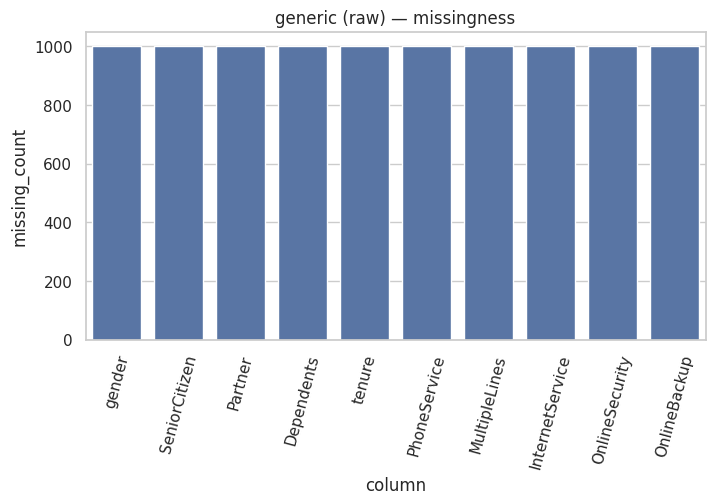

In [16]:
def inspect_raw(df, name, plots_dir):
    print(f"\n==== {name}: shape {df.shape} ====")
    display(df.head())
    print("\ndtypes:")
    display(df.dtypes.to_frame("dtype"))
    show_missingness(df, f"{name} (raw) — missingness", plots_dir, f"{name}_raw_missingness.png")

inspect_raw(generic, "generic", PLOTS_GENERIC_DIR)

In [17]:
# GENERIC
generic_numeric = ["Age","Tenure","Usage Frequency","Support Calls","Payment Delay","Total Spend","Last Interaction"]
coerce_numeric_inplace(generic, generic_numeric)

generic_rows_before = len(generic)

# drop any rows with missing values anywhere
generic_na_before = int(generic.isna().sum().sum())
if generic_na_before > 0:
    generic.dropna(inplace=True)
    generic.reset_index(drop=True, inplace=True)

# drop outliers by IQR on numeric columns
generic_iqr_stats, generic_outliers_dropped = drop_iqr_outliers_inplace(
    generic, generic_numeric, skip_binary=True
)

generic_rows_after = len(generic)

In [18]:
print("\ngeneric — summary stats (numeric, post-clean)")
display(generic[num_cols(generic)].describe())


generic — summary stats (numeric, post-clean)


,SeniorCitizen,tenure,Churn
count,3486.000000,3486.000000,3486.000000
mean,0.497992,35.934596,0.486517
std,0.500068,20.625979,0.499890
min,0.000000,1.000000,0.000000
25%,0.000000,18.000000,0.000000
50%,0.000000,36.000000,0.000000
75%,1.000000,54.000000,1.000000
max,1.000000,72.000000,1.000000


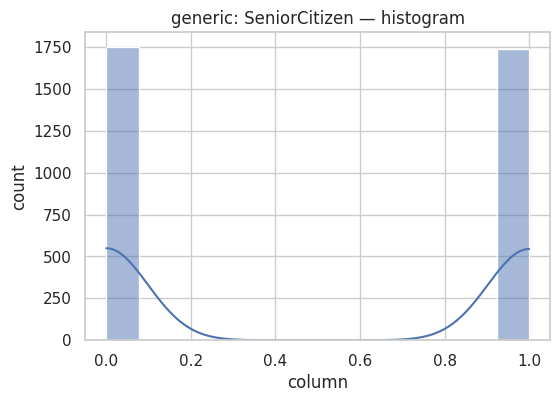

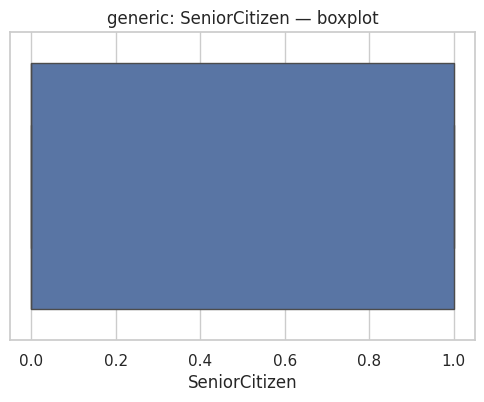

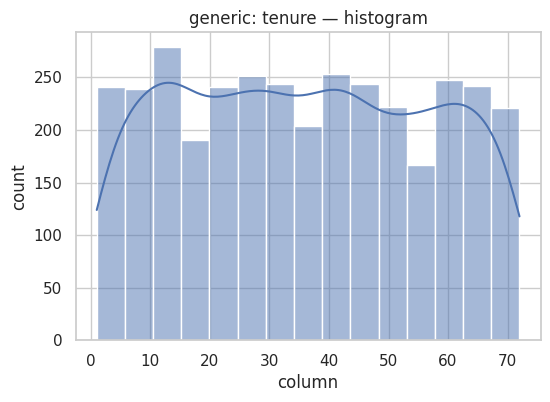

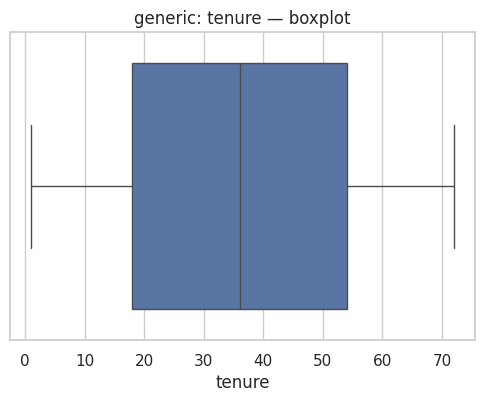

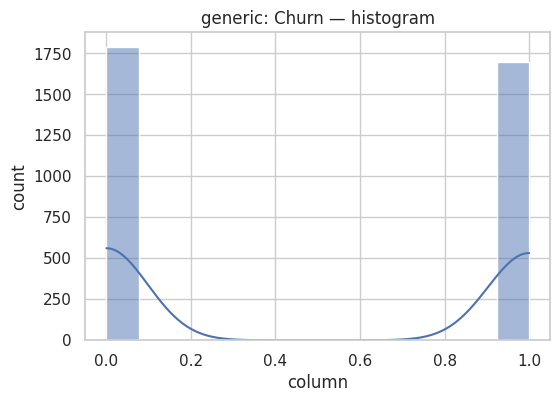

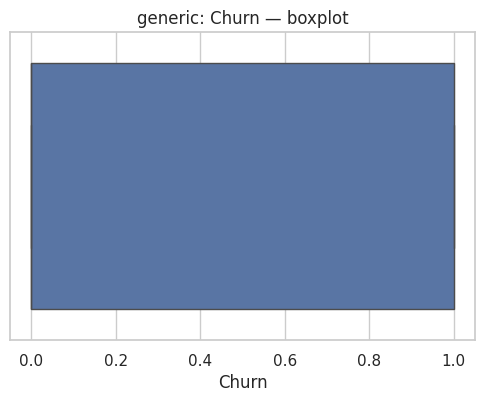

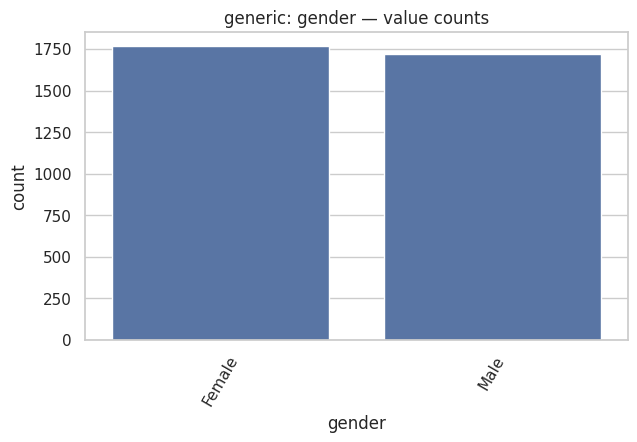

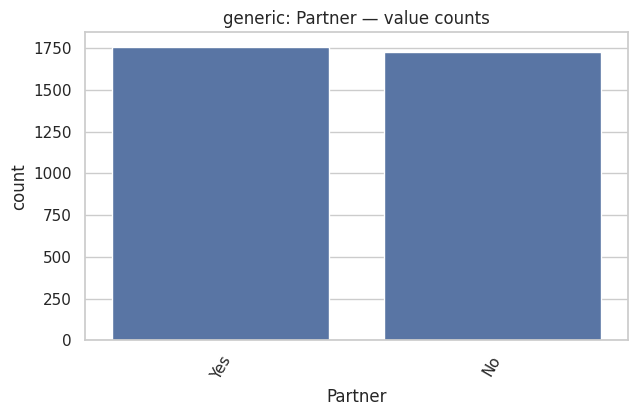

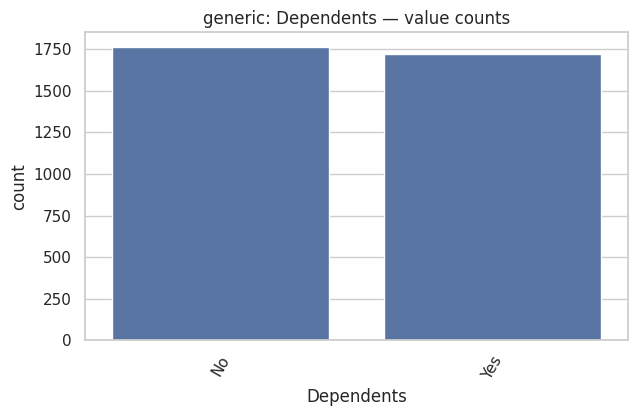

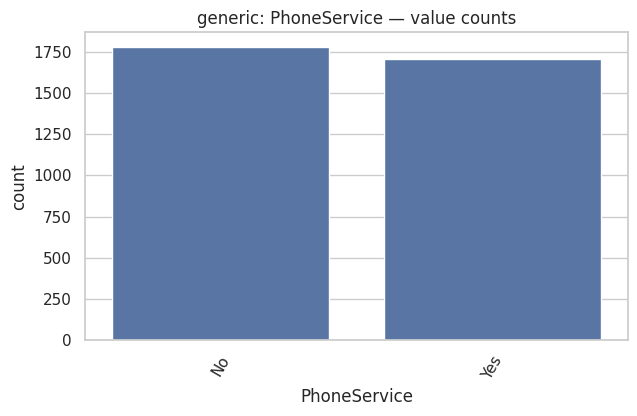

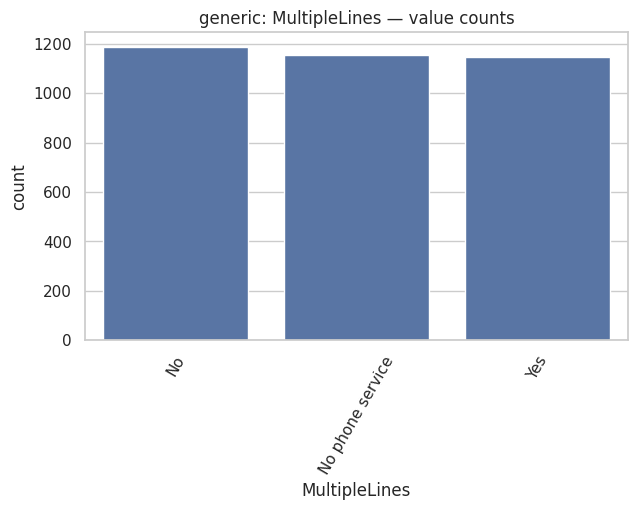

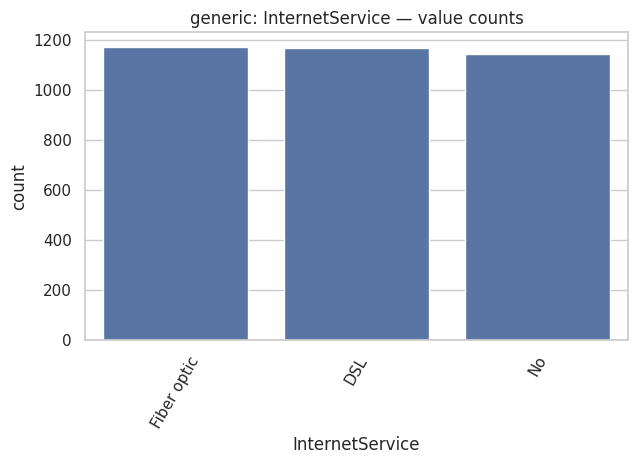

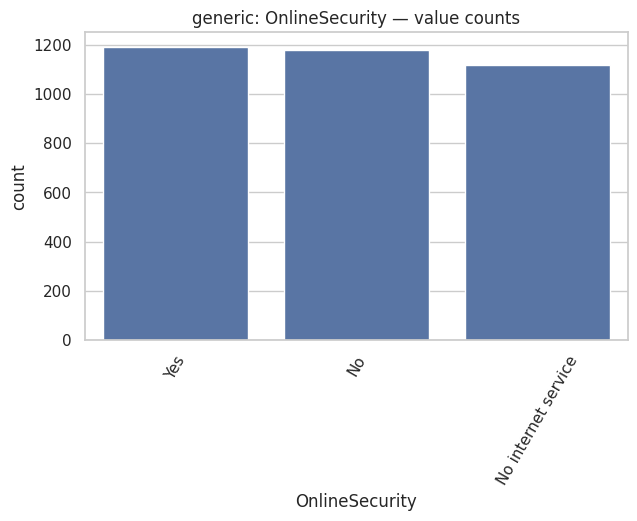

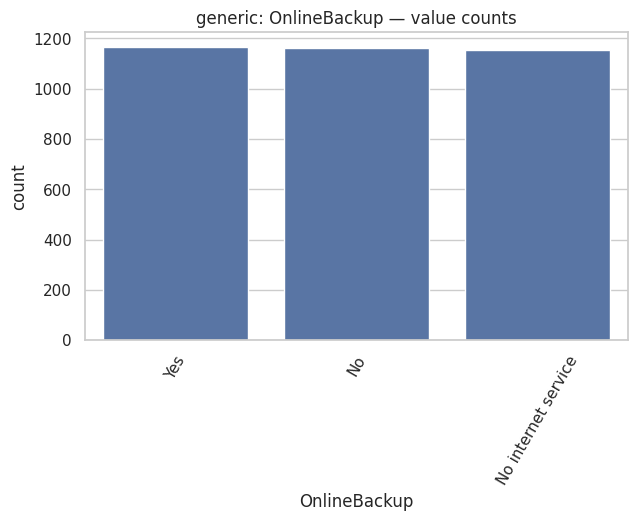

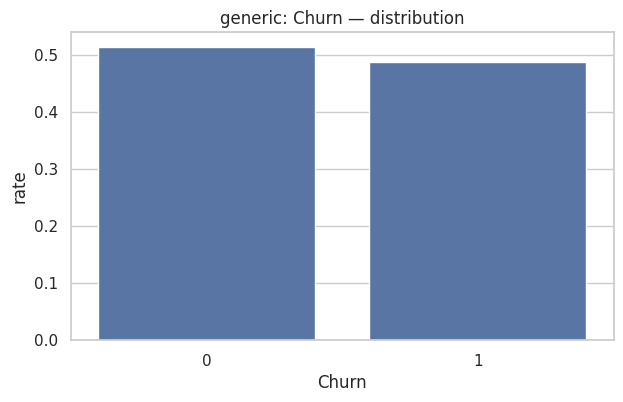

In [19]:
def univariate_plots(df, name, target, save_dir, max_cats=20):
    # numeric
    for c in num_cols(df):
        plot_hist(df, c, title=f"{name}: {c} — histogram", save_dir=save_dir, fname=f"{name}_{c}_hist.png")
        plot_box(df, c, title=f"{name}: {c} — boxplot", save_dir=save_dir, fname=f"{name}_{c}_box.png")

    # categoricals (simple): count plots for any non-numeric with moderate cardinality
    cat_candidates = [c for c in df.columns if c not in num_cols(df)]
    for c in cat_candidates:
        if df[c].nunique() <= max_cats:
            vc = df[c].value_counts(dropna=False)
            bar_series(vc, f"{name}: {c} — value counts", save_dir, f"{name}_{c}_counts.png", xlabel=c, ylabel="count", rotate=60)

    # target distribution (Churn)
    if target in df.columns:
        t = to_binary_series_like_churn(df[target])
        if pd.api.types.is_numeric_dtype(t):
            rate = t.value_counts(normalize=True).sort_index()
            bar_series(rate, f"{name}: {target} — distribution", save_dir, f"{name}_{target}_distribution.png", ylabel="rate")

univariate_plots(generic, "generic", TARGET_COL, PLOTS_GENERIC_DIR)

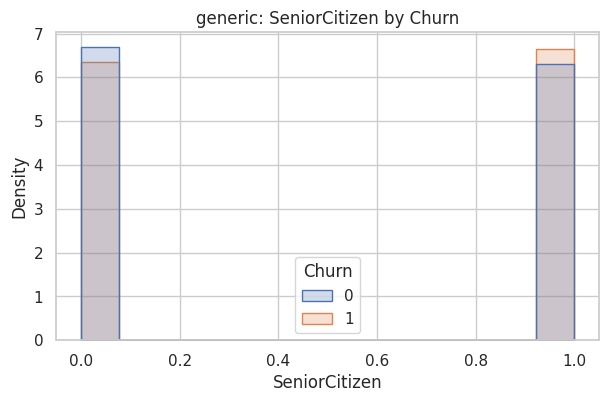

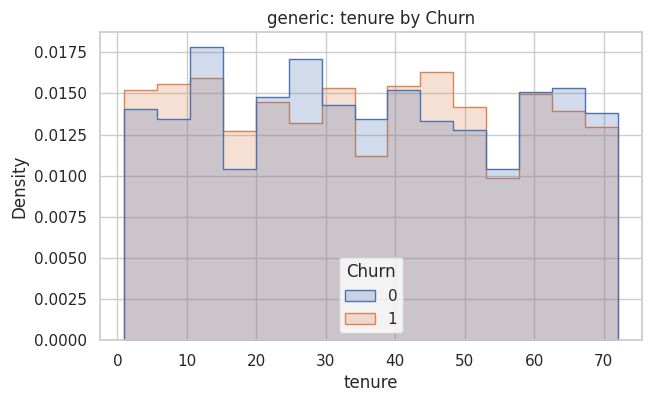

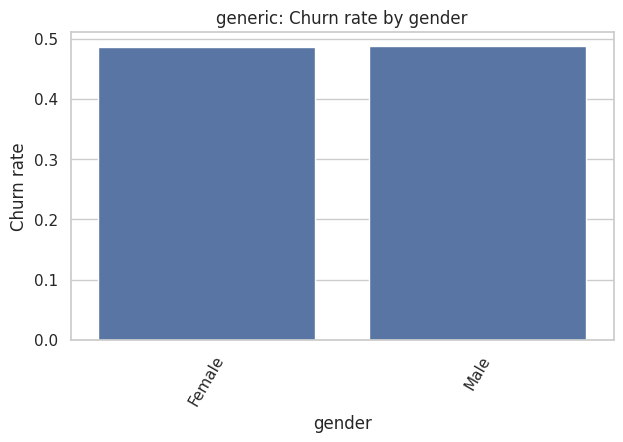

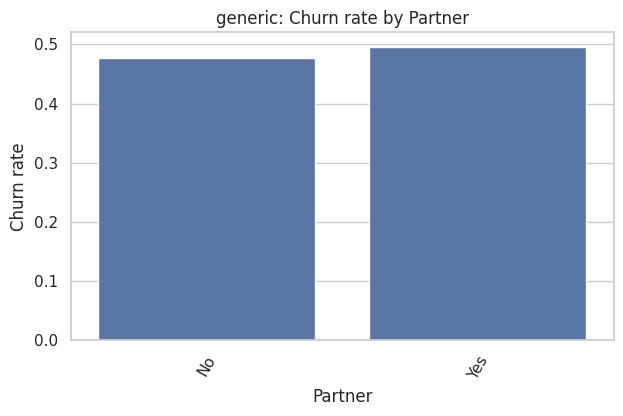

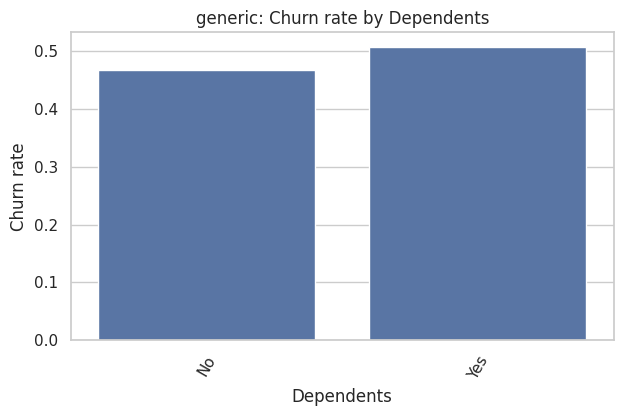

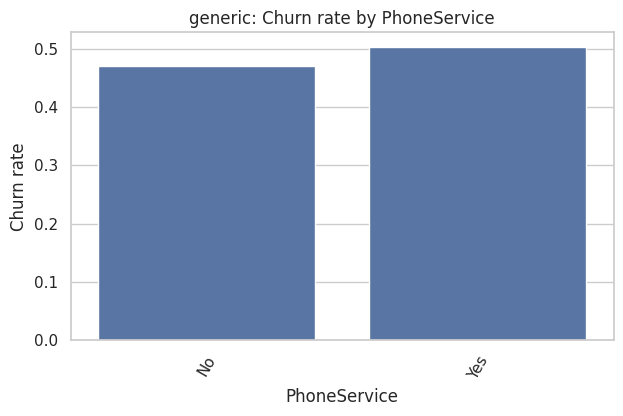

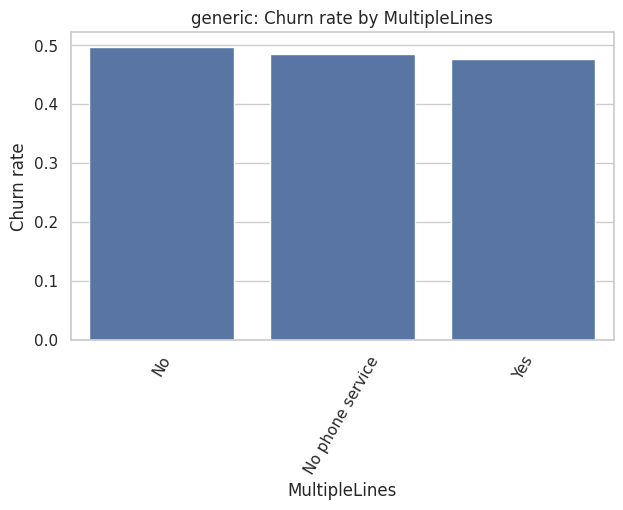

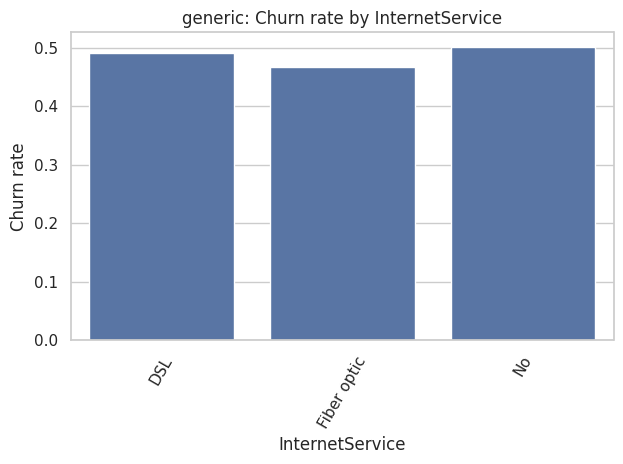

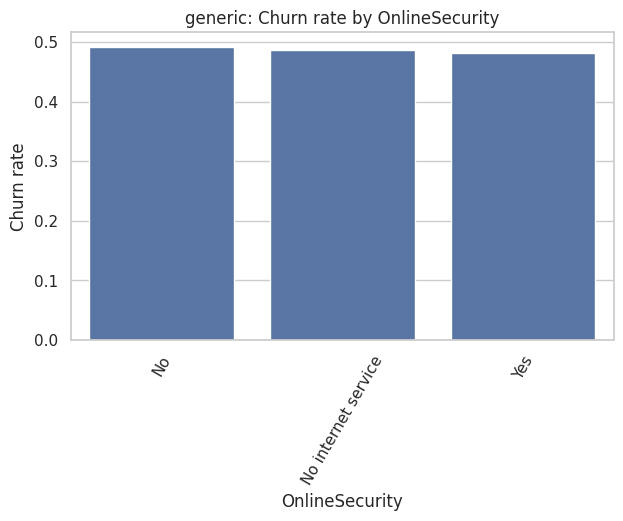

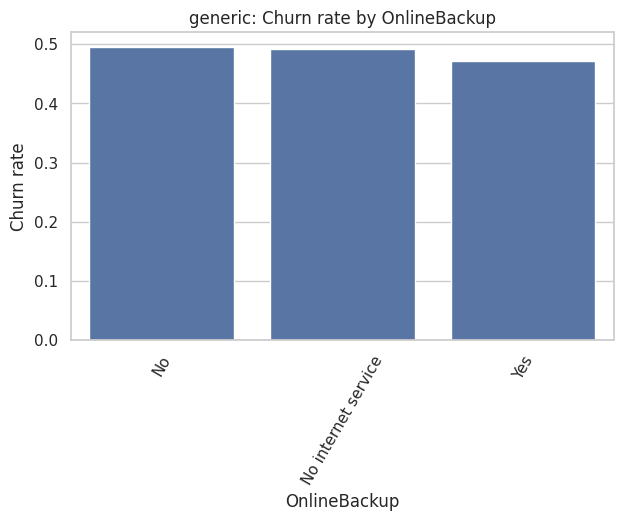

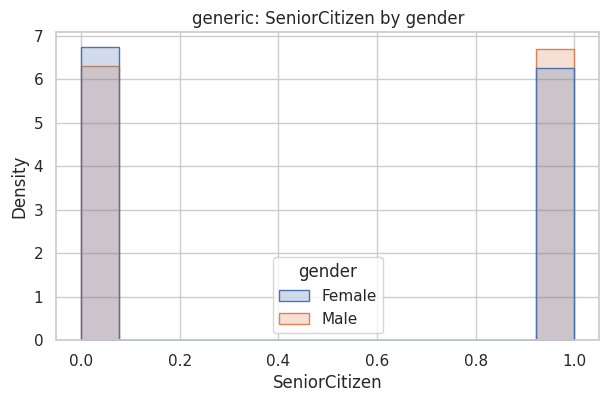

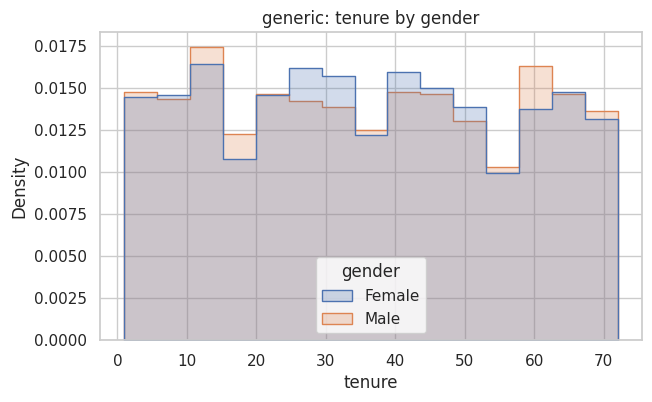

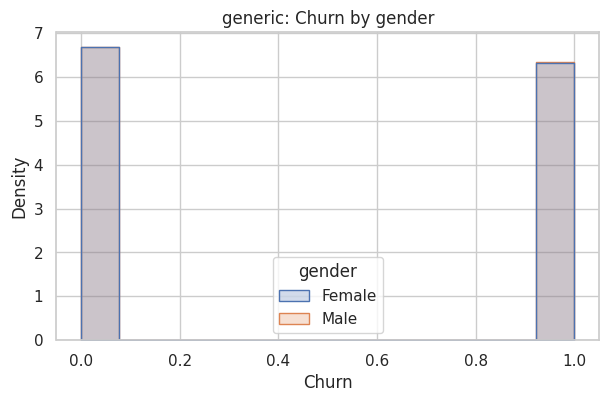

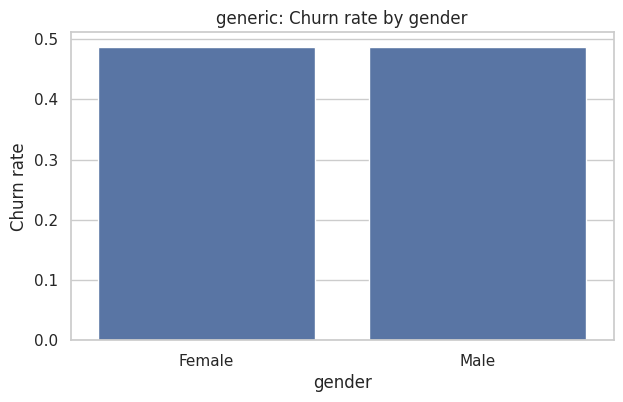

In [20]:
def bivariate_vs_target(df, name, target, save_dir):
    if target not in df.columns:
        print(f"{name}: no '{target}' column")
        return
    # numeric vs target: overlayed histograms
    for c in num_cols(df):
        if c == target:
            continue
        fig, ax = plt.subplots(figsize=(7,4))
        sns.histplot(data=df, x=c, hue=target, kde=False, ax=ax, element="step", stat="density", common_norm=False)
        ax.set_title(f"{name}: {c} by {target}")
        save_show(fig, os.path.join(save_dir, f"{name}_{c}_by_{target}.png"))

    # categorical → churn rate by category (target treated as binary 0/1)
    t = to_binary_series_like_churn(df[target])
    if pd.api.types.is_numeric_dtype(t):
        # recompute robustly to avoid alignment issues
        for c in [col for col in df.columns if col != target and col not in num_cols(df) and df[col].nunique() <= 25]:
            tmp = pd.DataFrame({c: df[c], "t": t}).dropna()
            rate = tmp.groupby(c)["t"].mean()
            bar_series(rate, f"{name}: {target} rate by {c}", save_dir, f"{name}_{target}_rate_by_{c}.png",
                       xlabel=c, ylabel=f"{target} rate", rotate=60)

def bivariate_vs_gender(df, name, save_dir, gender_col=None):
    gcol = gender_col or ("Gender" if "Gender" in df.columns else ("gender" if "gender" in df.columns else None))
    if not gcol:
        print(f"{name}: no gender column; skipping gender analysis")
        return
    # numeric distributions by gender
    for c in num_cols(df):
        fig, ax = plt.subplots(figsize=(7,4))
        sns.histplot(data=df, x=c, hue=gcol, kde=False, ax=ax, element="step", stat="density", common_norm=False)
        ax.set_title(f"{name}: {c} by {gcol}")
        save_show(fig, os.path.join(save_dir, f"{name}_{c}_by_{gcol}.png"))

    # target rate by gender
    if TARGET_COL in df.columns:
        t = to_binary_series_like_churn(df[TARGET_COL])
        if pd.api.types.is_numeric_dtype(t):
            tmp = pd.DataFrame({gcol: df[gcol], "t": t}).dropna()
            rate = tmp.groupby(gcol)["t"].mean()
            bar_series(rate, f"{name}: {TARGET_COL} rate by {gcol}", save_dir, f"{name}_{TARGET_COL}_rate_by_{gcol}.png",
                       xlabel=gcol, ylabel=f"{TARGET_COL} rate")

bivariate_vs_target(generic, "generic", TARGET_COL, PLOTS_GENERIC_DIR)
bivariate_vs_gender(generic, "generic", PLOTS_GENERIC_DIR, gender_col="gender")

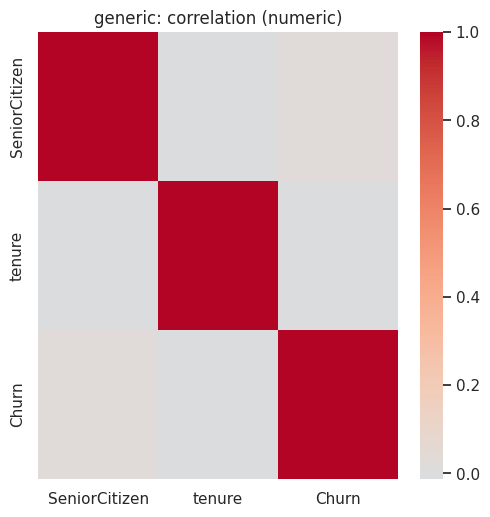

In [21]:
corr_heatmap(generic, "generic", PLOTS_GENERIC_DIR, "generic_correlation.png")

In [22]:
def total_outlier_drops(stats_dict):
    return int(sum(v.get("dropped", 0) for v in (stats_dict or {}).values()))

prep_summary = pd.DataFrame([
    {
        "dataset": "generic",
        "rows_before": generic_rows_before,
        "rows_after": generic_rows_after,
        "dropped_rows_missing_any": generic_na_before,
        "dropped_rows_outliers_total": total_outlier_drops(generic_iqr_stats),
        "clean_csv_path": GENERIC_OUT,
        "plots_dir": PLOTS_GENERIC_DIR
    }
])
# Date-Time conversion (add this in Cell 22, before encoding)
if "Last Interaction" in generic.columns:
    generic["Last Interaction"] = pd.to_datetime(generic["Last Interaction"], errors="coerce")
    ref = generic["Last Interaction"].max()
    generic["last_interaction_year"] = generic["Last Interaction"].dt.year
    generic["last_interaction_month"] = generic["Last Interaction"].dt.month
    generic["days_since_last_interaction"] = (ref - generic["Last Interaction"]).dt.days

print("=== DATA PREP SUMMARY ===")
display(prep_summary)

=== DATA PREP SUMMARY ===


,dataset,rows_before,rows_after,dropped_rows_missing_any,dropped_rows_outliers_total,clean_csv_path,plots_dir
0,generic,10000,3486,10000,0,/content/drive/MyDrive/DMML_Project/data/clean...,/content/drive/MyDrive/DMML_Project/data/plots...


## Encoding Categorical Variables  

Machine learning models require numerical inputs, so categorical variables must be converted into numeric form. In this project, we applied two common encoding strategies:  

- **Label Encoding**: Used for binary and ordinal features, where categories can be represented with integers  
  *(e.g., Yes/No → 1/0, SeniorCitizen: Yes/No)*.  
- **One-Hot Encoding**: Used for non-binary categorical features without a natural order  
  *(e.g., InternetService: DSL, Fiber optic, No)*. Each category is transformed into a separate binary column.  

### Approach Applied  
- **Generic dataset**  
  - **Label Encoding**: `Gender`, `Churn`  
  - **One-Hot Encoding**: `Subscription Type`, `Contract Length`  

### Dropped Columns  
Some columns were removed before encoding to prevent data leakage or redundancy:  
- **Generic**  
  - `CustomerID`: Unique identifier, no predictive value  
  - `Last Interaction`: Timestamp/order-based field, not meaningful as a raw input for prediction  

### Encoding Report (Examples)  

| Dataset | Column              | Encoding Type   | Mapping / Expansion |
|---------|---------------------|----------------|----------------------|
| Generic | `Gender`            | Label Encoding | Female=0, Male=1 |
| Generic | `Subscription Type` | One-Hot        | Basic, Standard, Premium → 3 binary cols |
| Generic | `Contract Length`   | One-Hot        | Monthly, Quarterly, Annual → 3 binary cols |


In [23]:
import pandas as pd
import numpy as np
print(generic.head())

ORDINAL_MAP = {
    "Contract Length": ["Monthly", "Quarterly", "Annual"],
    "Subscription Type": ["Basic", "Standard", "Premium"],
}

DROP_COLS = {
    "generic": ["CustomerID", "Last Interaction", "customerID"] # identifiers + timestamps
}



def is_numeric(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s)

def label_encode(series: pd.Series, order=None):
    #Return encoded series + mapping dict.
    if order is not None:
        mapping = {cat: i for i, cat in enumerate(order)}
        return series.map(mapping), mapping
    cats = series.dropna().unique().tolist()
    mapping = {cat: i for i, cat in enumerate(cats)}
    return series.map(mapping), mapping

def encode_dataset(df: pd.DataFrame, dataset_name: str, target_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Encoding rules:
      - target_col: if non-numeric, map Yes/No/True/False/1/0 -> 1/0; else fallback to label-encode
      - FORCE_BINARY_LABEL: force listed cols to be label-encoded with provided order (e.g., SeniorCitizen)
      - ORDINAL_MAP: label-encode with given order (for truly ordinal categories)
      - remaining binary categoricals (2 unique values) -> label-encode
      - remaining non-numeric categoricals -> one-hot (drop_first=True)
    """
    work = df.copy()
    report = []

    # Drop unwanted ID / leakage columns FIRST
    cols_to_drop = DROP_COLS.get(dataset_name, [])
    existing_cols_to_drop = [c for c in cols_to_drop if c in work.columns]
    if existing_cols_to_drop:
        work.drop(columns=existing_cols_to_drop, inplace=True)
        for c in existing_cols_to_drop:
             report.append({
                "dataset": dataset_name, "column": c,
                "method": "dropped",
                "details": "identifier/leakage column removed"
            })


    # 0) Ensure target is numeric 0/1 (if present and non-numeric)
    if target_col in work.columns and not is_numeric(work[target_col]):
        mapping = {"yes":1, "no":0, "true":1, "false":0, "1":1, "0":0}
        lower = work[target_col].astype(str).str.lower().str.strip()
        enc = lower.map(mapping)
        if enc.notna().mean() < 0.6:  # fallback: label-encode by unique categories
            enc, cat_map = label_encode(work[target_col])
            report.append({
                "dataset": dataset_name, "column": target_col,
                "method": "label (fallback)",
                "details": f"mapping={cat_map}"
            })
        else:
            report.append({
                "dataset": dataset_name, "column": target_col,
                "method": "binary map",
                "details": "yes/true/1 -> 1, no/false/0 -> 0"
            })
        work[target_col] = enc.astype("Int64")

    # 1) Apply explicit ordinal encodings
    for c, order in ORDINAL_MAP.items():
        if c in work.columns:
            enc, cat_map = label_encode(work[c], order)
            work[c] = enc.astype("Int64")
            report.append({
                "dataset": dataset_name, "column": c,
                "method": "label (ordinal)",
                "details": f"order={order}"
            })

    # 2) Remaining non-numeric features
    feature_cols = [c for c in work.columns if c != target_col]
    non_numeric = [c for c in feature_cols if not is_numeric(work[c])]

    # 2a) Label-encode binary categoricals
    for c in list(non_numeric):
        unique_non_null = work[c].dropna().unique()
        if len(unique_non_null) == 2:
            enc, cat_map = label_encode(work[c])
            work[c] = enc.astype("Int64")
            report.append({
                "dataset": dataset_name, "column": c,
                "method": "label (binary)",
                "details": f"mapping={cat_map}"
            })
    # Refresh non-numeric after binary encoding
    non_numeric = [c for c in work.columns if c != target_col and not is_numeric(work[c])]


    # 2b) One-hot encode remaining categoricals
    if non_numeric:
        k_info = {c: int(work[c].nunique(dropna=True)) for c in non_numeric}
        work = pd.get_dummies(work, columns=non_numeric, drop_first=True)
        for c, k in k_info.items():
            report.append({
                "dataset": dataset_name, "column": c,
                "method": "one-hot (drop_first)",
                "details": f"categories={k}, dummies_created={max(k-1,0)}"
            })

    report_df = pd.DataFrame(report, columns=["dataset","column","method","details"])
    return work, report_df

if "Last Interaction" in generic.columns:
    generic["Last Interaction"] = pd.to_datetime(generic["Last Interaction"], errors="coerce")
    now_ts = generic["Last Interaction"].max() if generic["Last Interaction"].notna().any() else pd.Timestamp.now()
    generic["last_interaction_year"] = generic["Last Interaction"].dt.year
    generic["last_interaction_month"] = generic["Last Interaction"].dt.month
    generic["days_since_last_interaction"] = (now_ts - generic["Last Interaction"]).dt.days
# ----- Run encoding for generic dataset -----
generic_encoded, generic_report = encode_dataset(generic, "generic", TARGET_COL)

# ----- SAVE TIMESTAMPED CLEAN FILES (as requested) -----
generic_clean_path = f"{GENERIC_OUT}/generic_clean_{TS}.csv"
generic_encoded.to_csv(generic_clean_path, index=False)

print("\nSaved clean dataset:")
print("  generic→", generic_clean_path)

# ----- Print what was encoded and how -----
print("\n=== ENCODING REPORT — Generic ===")
display(generic_report)


print("\nGeneric encoded shape:", generic_encoded.shape)

  customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Cust_6  Female            0.0      No         No    32.0          Yes   
1    Cust_10  Female            0.0     Yes        Yes    70.0           No   
2    Cust_11    Male            0.0     Yes         No    51.0          Yes   
3    Cust_14    Male            0.0      No        Yes    10.0           No   
4    Cust_15  Female            0.0     Yes        Yes    19.0          Yes   

  MultipleLines InternetService       OnlineSecurity OnlineBackup  Churn  
0           Yes             DSL                  Yes          Yes      1  
1           Yes              No                  Yes          Yes      1  
2            No     Fiber optic                   No          Yes      1  
3           Yes              No                  Yes          Yes      0  
4           Yes             DSL  No internet service          Yes      0  

Saved clean dataset:
  generic→ /content/drive/MyDrive/DMML_Project/data/c

,dataset,column,method,details
0,generic,customerID,dropped,identifier/leakage column removed
1,generic,gender,label (binary),"mapping={'Female': 0, 'Male': 1}"
2,generic,Partner,label (binary),"mapping={'No': 0, 'Yes': 1}"
3,generic,Dependents,label (binary),"mapping={'No': 0, 'Yes': 1}"
4,generic,PhoneService,label (binary),"mapping={'Yes': 0, 'No': 1}"
5,generic,MultipleLines,one-hot (drop_first),"categories=3, dummies_created=2"
6,generic,InternetService,one-hot (drop_first),"categories=3, dummies_created=2"
7,generic,OnlineSecurity,one-hot (drop_first),"categories=3, dummies_created=2"
8,generic,OnlineBackup,one-hot (drop_first),"categories=3, dummies_created=2"



Generic encoded shape: (3486, 15)


## Loading the Latest Version of Clean Data

In this step, we are **automating the data loading process** from our Clean storage.  
Since the ingestion pipeline saves new versions of the  dataset with a timestamped filename, we do not want to hardcode a specific file.  

Instead, the script:
- Scans the Clean data folder
- Identifies all available CSV files
- Automatically selects the **latest version** based on its modification time

This ensures that the analysis and downstream processing always run on the most up-to-date data without manual intervention.


In [24]:
import glob

# Find all CSVs inside that folder
csv_files = glob.glob(os.path.join(GENERIC_OUT, "*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {GENERIC_OUT}")

# Sort by modification time and pick the latest
latest_file = max(csv_files, key=os.path.getmtime)
print("Latest file found:", latest_file)

# Load into DataFrame
df_generic_clean = pd.read_csv(latest_file)
print("Shape:", df_generic_clean.shape)
df_generic_clean.head()

Latest file found: /content/drive/MyDrive/DMML_Project/data/clean/generic/generic_clean_20250823T152443.csv
Shape: (3486, 15)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes
0,0,0.0,0,0,32.0,0,1,False,True,False,False,False,True,False,True
1,0,0.0,1,1,70.0,1,1,False,True,False,True,False,True,False,True
2,1,0.0,1,0,51.0,0,1,False,False,True,False,False,False,False,True
3,1,0.0,0,1,10.0,1,0,False,True,False,True,False,True,False,True
4,0,0.0,1,1,19.0,0,0,False,True,False,False,True,False,False,True
